In [13]:
# Demo for DataLoader
from torch.utils.data import DataLoader

data = [1,2,3,4,5]

loader = DataLoader(data, batch_size=10, shuffle=True)

for batch in loader:
    print(batch)


tensor([5, 1, 2, 4, 3])


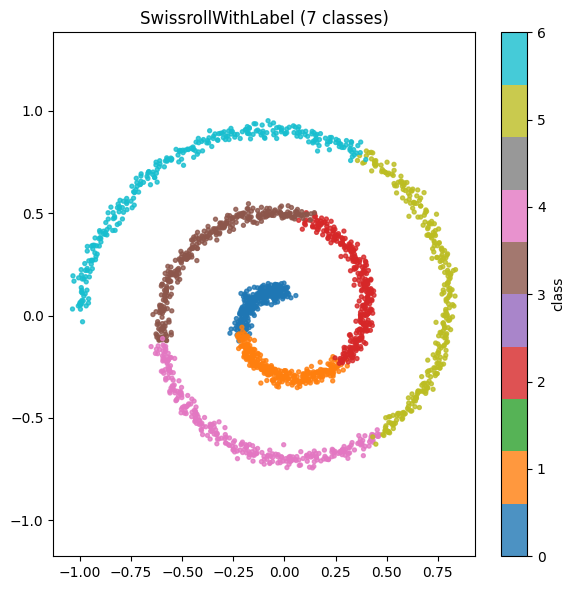

In [3]:
import importlib
import data as _data_mod
importlib.reload(_data_mod)

import matplotlib.pyplot as plt
import numpy as np
from data import SwissrollWithLabel

dataset = SwissrollWithLabel()
pts = np.array([dataset[i][0].numpy() for i in range(len(dataset))])
labels = np.array([dataset[i][1] for i in range(len(dataset))])

plt.figure(figsize=(6, 6))
scatter = plt.scatter(pts[:, 0], pts[:, 1], c=labels, cmap='tab10', s=8, alpha=0.8)
plt.colorbar(scatter, label='class')
plt.axis('equal')
plt.title('SwissrollWithLabel (7 classes)')
plt.tight_layout()
plt.show()


In [5]:
from itertools import pairwise
a = (1 + 2,) + (1,2,3)

for i,j in pairwise(a):
    print(i,j)

3 1
1 2
2 3


In [18]:
from model import CondEmbedderLabel
import torch

# Demo for CondEmbedderLabel usage
cond_embed = CondEmbedderLabel(4, 7, 0)

labels = torch.tensor([0, 0, 0])

cond_embed(labels)



tensor([[-0.9133, -0.1326,  0.4349,  1.6648],
        [-0.9133, -0.1326,  0.4349,  1.6648],
        [-0.9133, -0.1326,  0.4349,  1.6648]], grad_fn=<EmbeddingBackward0>)

In [36]:
# Demo for state_dict
import torch
import torch.nn as nn

# Define a simple model
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(1, 2)
        self.fc2 = nn.Linear(2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Create an instance of the model
model = MyModel()

# Create a state_dict
state_dict = model.state_dict()

# Print the state_dict
for key, value in state_dict.items():
    print(key, value)


fc1.weight tensor([[-0.7147],
        [ 0.5051]])
fc1.bias tensor([-0.4231,  0.3941])
fc2.weight tensor([[ 0.0679, -0.0068]])
fc2.bias tensor([0.4753])


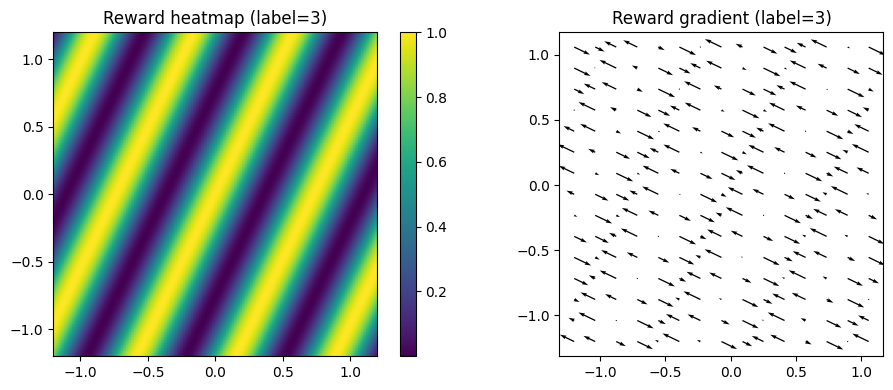

In [49]:
import importlib
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import model; importlib.reload(model)
from model import Reward2D

def visualize_reward(reward_fn, label: int = 3, n: int = 120):
    xs = torch.linspace(-1.2, 1.2, n)
    ys = torch.linspace(-1.2, 1.2, n)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

    y = torch.full((grid.size(0),), label, dtype=torch.long)

    with torch.no_grad():
        R = reward_fn(grid, y).reshape(n, n)

    grid2 = grid.clone().requires_grad_(True)
    y2 = torch.full((grid2.size(0),), label, dtype=torch.long)
    r = reward_fn(grid2, y2).sum()
    grad = torch.autograd.grad(r, grid2)[0].reshape(n, n, 2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im = axes[0].imshow(
        R, origin="lower",
        extent=[xs.min(), xs.max(), ys.min(), ys.max()],
        aspect="equal",
    )
    axes[0].set_title(f"Reward heatmap (label={label})")
    plt.colorbar(im, ax=axes[0])

    step = 8
    axes[1].quiver(
        X[::step, ::step], Y[::step, ::step],
        grad[..., 0][::step, ::step].detach(),
        grad[..., 1][::step, ::step].detach(),
    )
    axes[1].set_title(f"Reward gradient (label={label})")
    axes[1].set_aspect("equal")

    plt.tight_layout()
    plt.show()


reward_fn = Reward2D(num_classes=7)
visualize_reward(reward_fn, label=3)

In [ ]:
# demo for view()

t = torch.tensor([1,2,3,4,5,6,7,8])
t = t.view(4, 2)        # Grouping, t.shape = [4,2], t = [[1,2],[3,4],[5,6],[7,8]]
t = t.view(2, -1, 2)    # -1 represents to compute that dimension automatically, same as view(2, 2, 2)
                        # t = [[[1,2],[3,4]],[[5,6],[7,8]]]
t = t.view(-1)          # Flatten all, t = [1,2,3,4,5,6,7,8]
print(t)

tensor([1, 2, 3, 4, 5, 6, 7, 8])


In [69]:
t = torch.randn(5,6,7,8)

a = t.dim()

print(a)


4
